In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data from .csv file
geopolitical_events = pd.read_csv('../data/geopolitical_events_timeline.csv')
geopolitical_events.head()

,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8


In [3]:
# Get datatypes of columns to check if we need to clean anything
geopolitical_events.dtypes

date                   str
event_type             str
event_description      str
event_severity       int64
dtype: object

In [4]:
# Convert data to DateTime so we can get data such as the Year, Month, and Day easily.
events_dates = pd.to_datetime(geopolitical_events['date'], format="%Y-%m-%d")
geopolitical_events['date'] = events_dates
geopolitical_events.dtypes

date                 datetime64[us]
event_type                      str
event_description               str
event_severity                int64
dtype: object

# Questions
Since the goal is to obtain a deeper understanding of oil geopolitics and how current events have been shaping it, I want to understand the following:
1. What year was the most eventful?
2. What event type is the most common?
3. What is the most common level of event severity?
4. Are events becoming more frequent now compared to before?
5. Is the event severity of different event types going up or going down?
6. What countries are playing the biggest roles in affecting the oil market?
7. Are high severity events becoming more common over time?
8. What do the most severe events have in common?

Let's begin!

## What year was the most eventful?
To answer this, we can visualize the data using a histogram to display the distribution of occurrences between different years.

In [5]:
# Get the years
years = geopolitical_events['date'].dt.year

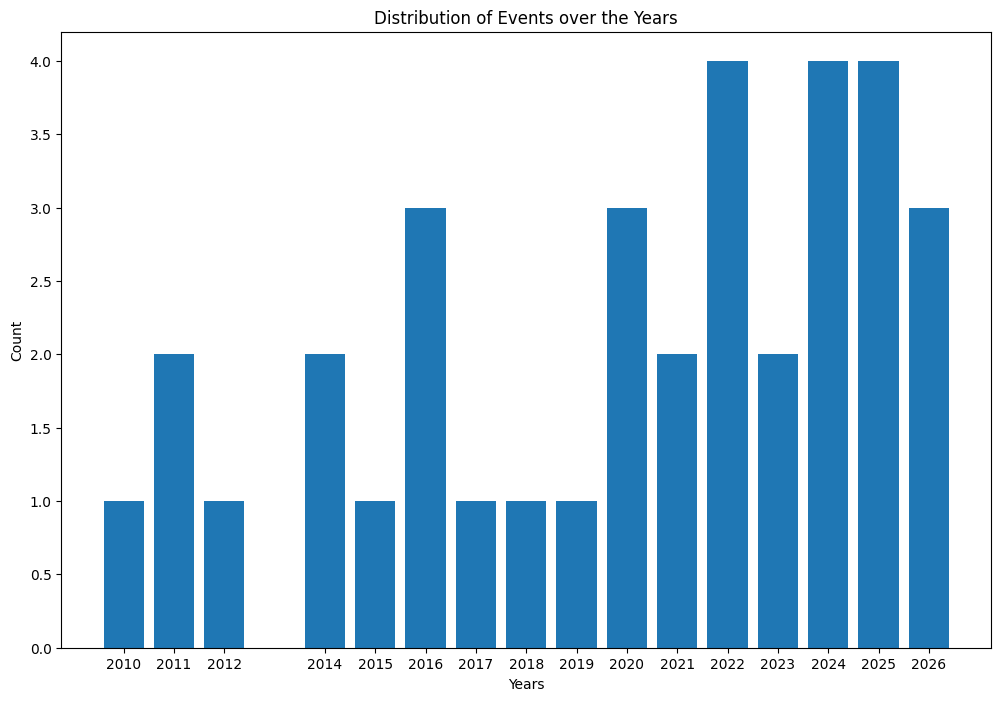

In [6]:
# Get the x and y axis of the plot
label = years.unique()
count = years.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12,8))

ax.bar(label, count)
ax.set_xticks(label)

plt.title("Distribution of Events over the Years")
plt.xlabel("Years")
plt.ylabel("Count")
plt.show();

From the visualization, we can see that the most eventful year is a tie between **2022**, **2024**, and **2025** with 4 events each. With 2016, 2020, and 2026 coming in 2nd with 3 events each. It is quite concerning that 2026 already has 3 events, considering that as of creating this notebook, it is only March of 2026.

## What Event Type is the Most Common
To determine what event type is the most common, we can visualize this categorical data using a **pie chart**. This will help us understand the distribution of event types.

In [ ]:
# TODO: Recreate Pie Chart to properly display the data.
# Previous iteration was wrong !

<StringArray>
[         'disaster',               'war',         'sanctions',
        'annexation',              'opec', 'diplomatic_crisis',
            'attack',          'conflict',     'oil_price_war',
      'market_crash',          'blockage',     'energy_crisis',
          'blockade',      'market_shift']
Length: 14, dtype: str

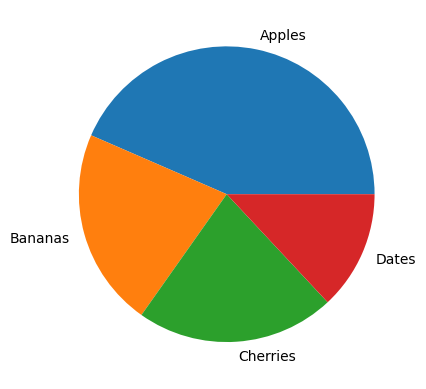

In [ ]:
events = geopolitical_events['event_type']

data_dict = {}



labels = list(data_dict.keys())
values = list(data_dict.values())

fig, ax = plt.subplots()

ax.pie(values, labels=labels)
plt.show()

In [28]:
geopolitical_events['event_type'].value_counts()

event_type
sanctions            7
opec                 6
conflict             6
war                  5
blockade             2
disaster             1
annexation           1
diplomatic_crisis    1
attack               1
oil_price_war        1
market_crash         1
blockage             1
energy_crisis        1
market_shift         1
Name: count, dtype: int64

From the visualization above, the most common type of event is `disaster` with 20%, followed by `war` and `sanctions`, with 17.1% each. `annexation` and `opec` come in 3rd and 4th place with 14.3% and 5.7% respectively.

## What was the Most Common Event Severity Level?
To understand what severity level was the most common, we use a histogram.

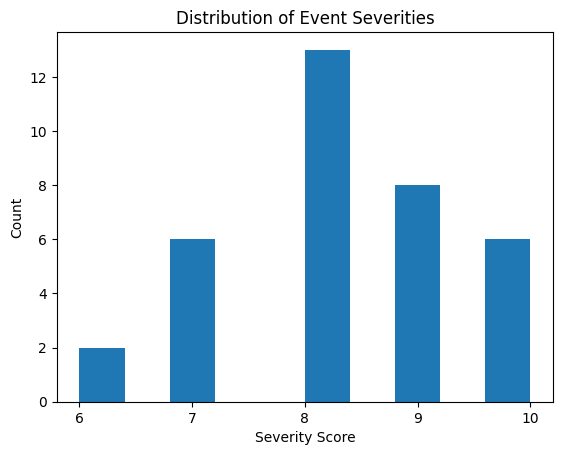

In [8]:
severities = geopolitical_events['event_severity']

fig, ax = plt.subplots()

ax.hist(severities)
ax.set_xticks(severities.unique())

plt.title("Distribution of Event Severities")
plt.xlabel("Severity Score")
plt.ylabel("Count")

plt.show();

From the visualization above, we can say that `8` is the most common severity level assigned to events, with `6` being the least common.

## Are Events Becoming More Frequent Compared to Before?
This question will help us understand whether or not the market is becoming more unstable in the present, as opposed to the past. To answer this question, we get the number of events that occurred per year and plot it with a line graph to understand the trend.

Actually, we can already answer this using the visualization we used for question #1, but using a line graph will help us better understand the trend, rather than just the number of events as a discrete value.

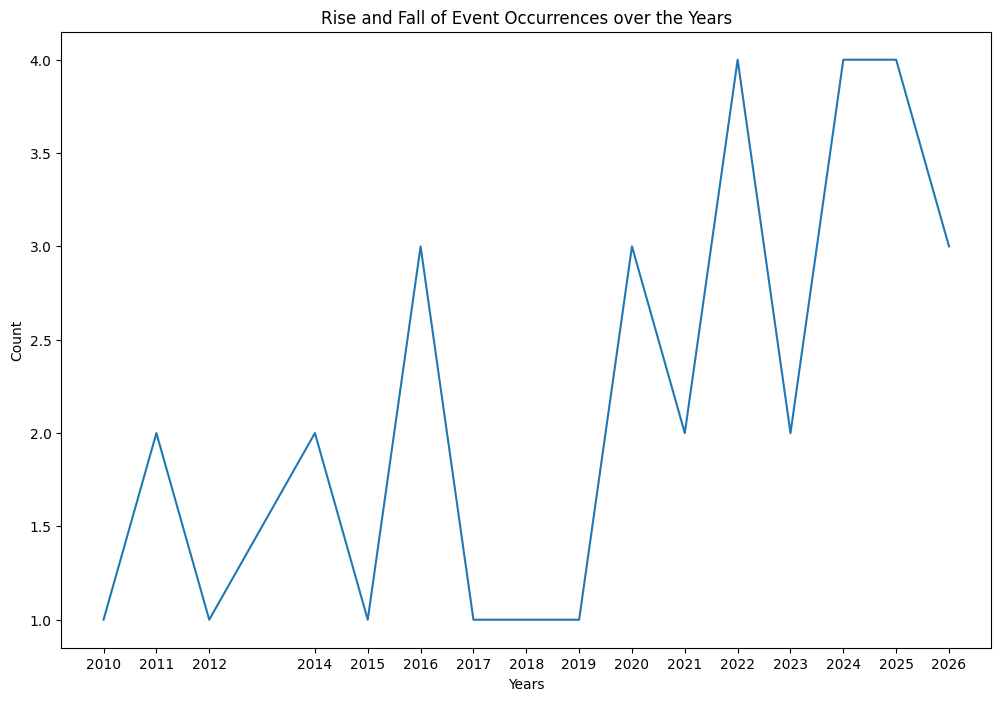

In [9]:
years = geopolitical_events['date'].dt.year.unique()
occurrences = geopolitical_events['date'].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(occurrences)
ax.set_xticks(years)

plt.title("Rise and Fall of Event Occurrences over the Years")
plt.xlabel("Years")
plt.ylabel("Count")

plt.show();

From the chart above, I think we can make the conclusion that more events are happening now than before. If you compare it prior to the year 2019, some years would only have 1 event, with the highest number of events happening in 2016, with 3 events. From 2019 onwards however, the lowest number of incidents that happened in a year was 2 instead of 1 (2021 and 2023). Furthermore, we saw years with the most number of incidents by far, with 2022, 2024, and 2025 with 4 events each, which was never seen prior to 2019.

## Is the event severity of different event types going up or going down?
To do this, we must get each event type with multiple instances, and plot their values over the years. Instead of doing this for every event type, I will focus on four: `sanctions`, `war`, and `disaster`, and `annexation`. The reason I want to focus on these, is because these four event types make up more than half of all the events that have occurred (68.5%).

In [27]:
sanction_events = geopolitical_events[geopolitical_events['event_type'] == 'sanctions']
war_events = geopolitical_events[geopolitical_events['event_type'] == 'war']
disaster_events = geopolitical_events[geopolitical_events['event_type'] == 'disaster']
annexation_events = geopolitical_events[geopolitical_events['event_type'] == 'annexation']

disaster_events


,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
